In [2]:
!pip install google-ml-edu==0.1.3 \
  keras~=3.8.0 \
  matplotlib~=3.10.0 \
  numpy~=2.0.0 \
  pandas~=2.2.0 \
  tensorflow~=2.18.0

print('\n\nAll requirements successfully installed.')



All requirements successfully installed.


In [3]:
import numpy as np
import pandas as pd
import keras
import ml_edu.experiment
import ml_edu.results

import plotly.express as px

/usr/local/lib/python3.12/dist-packages/jax/_src/cloud_tpu_init.py:86: UserWarning: Transparent hugepages are not enabled. TPU runtime startup and shutdown time should be significantly improved on TPU v5e and newer. If not already set, you may need to enable transparent hugepages in your VM image (sudo sh -c "echo always > /sys/kernel/mm/transparent_hugepage/enabled")
  warnings.warn(


In [4]:
chicago_taxi_dataset = pd.read_csv("https://download.mlcc.google.com/mledu-datasets/chicago_taxi_train.csv")

In [5]:
training_df = chicago_taxi_dataset.loc[:,('TRIP_MILES', 'TRIP_SECONDS', 'FARE', 'COMPANY', 'PAYMENT_TYPE', 'TIP_RATE')]

print("Read Dataset Success")
print('Total number of rows: {0}\n\n'.format(len(training_df.index)))
training_df.head(200)

Read Dataset Success
Total number of rows: 31694




,TRIP_MILES,TRIP_SECONDS,FARE,COMPANY,PAYMENT_TYPE,TIP_RATE
0,2.57,2341,31.99,Flash Cab,Mobile,6.3
1,1.18,1074,9.75,Flash Cab,Credit Card,27.9
2,1.29,1173,10.25,Sun Taxi,Cash,0.0
3,3.70,3360,23.75,Choice Taxi Association,Cash,0.0
4,1.15,1044,10.00,Flash Cab,Cash,0.0
...,...,...,...,...,...,...
195,1.13,821,9.00,Blue Ribbon Taxi Association,Mobile,22.9
196,0.57,414,6.00,Flash Cab,Cash,0.0
197,1.22,886,9.00,City Service,Cash,0.0
198,1.68,1219,9.00,Sun Taxi,Mobile,23.0


In [6]:
print('Total Numbers of rows: {0}\n\n '.format(len(training_df.index)))
training_df.describe(include='all')

Total Numbers of rows: 31694

 


,TRIP_MILES,TRIP_SECONDS,FARE,COMPANY,PAYMENT_TYPE,TIP_RATE
count,31694.000000,31694.000000,31694.000000,31694,31694,31694.000000
unique,NaN,NaN,NaN,31,7,NaN
top,NaN,NaN,NaN,Flash Cab,Credit Card,NaN
freq,NaN,NaN,NaN,7887,14142,NaN
mean,8.289463,1319.796397,23.905210,NaN,NaN,12.965785
std,7.265672,928.932873,16.970022,NaN,NaN,15.517765
min,0.500000,60.000000,3.250000,NaN,NaN,0.000000
25%,1.720000,548.000000,9.000000,NaN,NaN,0.000000
50%,5.920000,1081.000000,18.750000,NaN,NaN,12.200000
75%,14.500000,1888.000000,38.750000,NaN,NaN,20.800000


In [7]:
# What is the maximum fare?
max_fare = training_df['FARE'].max()
print("What is the maximum fare? 				Answer: ${fare:.2f}".format(fare = max_fare))

# What is the mean distance across all trips?
mean_distance = training_df['TRIP_MILES'].mean()
print("What is the mean distance across all trips? 		Answer: {mean:.4f} miles".format(mean = mean_distance))

# How many cab companies are in the dataset?
num_unique_companies =  training_df['COMPANY'].nunique()
print("How many cab companies are in the dataset? 		Answer: {number}".format(number = num_unique_companies))

# What is the most frequent payment type?
most_freq_payment_type = training_df['PAYMENT_TYPE'].value_counts().idxmax()
print("What is the most frequent payment type? 		Answer: {type}".format(type = most_freq_payment_type))

# Are any features missing data?
missing_values = training_df.isnull().sum().sum()
print("Are any features missing data? 				Answer:", "No" if missing_values == 0 else "Yes")

What is the maximum fare? 				Answer: $159.25
What is the mean distance across all trips? 		Answer: 8.2895 miles
How many cab companies are in the dataset? 		Answer: 31
What is the most frequent payment type? 		Answer: Credit Card
Are any features missing data? 				Answer: No


In [8]:
training_df.corr(numeric_only=True)

,TRIP_MILES,TRIP_SECONDS,FARE,TIP_RATE
TRIP_MILES,1.000000,0.800855,0.975344,-0.049594
TRIP_SECONDS,0.800855,1.000000,0.830292,-0.084294
FARE,0.975344,0.830292,1.000000,-0.070979
TIP_RATE,-0.049594,-0.084294,-0.070979,1.000000


In [9]:
px.scatter_matrix(training_df, dimensions=["FARE", "TRIP_MILES", "TRIP_SECONDS"])

In [10]:
def create_model(
    settings: ml_edu.experiment.ExperimentSettings,
    metrics: list[keras.metrics.Metric],
) -> keras.Model:
  """Create and compile a simple linear regression model."""
  # Describe the topography of the model.
  # The topography of a simple linear regression model
  # is a single node in a single layer.
  inputs = {name: keras.Input(shape=(1,), name=name) for name in settings.input_features}
  concatenated_inputs = keras.layers.Concatenate()(list(inputs.values()))
  outputs = keras.layers.Dense(units=1)(concatenated_inputs)
  model = keras.Model(inputs=inputs, outputs=outputs)

  # Compile the model topography into code that Keras can efficiently
  # execute. Configure training to minimize the model's mean squared error.
  model.compile(optimizer=keras.optimizers.RMSprop(learning_rate=settings.learning_rate),
                loss="mean_squared_error",
                metrics=metrics)

  return model


def train_model(
    experiment_name: str,
    model: keras.Model,
    dataset: pd.DataFrame,
    label_name: str,
    settings: ml_edu.experiment.ExperimentSettings,
) -> ml_edu.experiment.Experiment:
  """Train the model by feeding it data."""

  # Feed the model the feature and the label.
  # The model will train for the specified number of epochs.
  features = {name: dataset[name].values for name in settings.input_features}
  label = dataset[label_name].values
  history = model.fit(x=features,
                      y=label,
                      batch_size=settings.batch_size,
                      epochs=settings.number_epochs)

  return ml_edu.experiment.Experiment(
      name=experiment_name,
      settings=settings,
      model=model,
      epochs=history.epoch,
      metrics_history=pd.DataFrame(history.history),
  )

print("SUCCESS: defining linear regression functions complete.")

SUCCESS: defining linear regression functions complete.


Epoch 1/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 1s 748us/step - loss: 104.9769 - rmse: 10.2054
Epoch 2/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 0s 751us/step - loss: 26.3965 - rmse: 5.1257
Epoch 3/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 0s 723us/step - loss: 19.1282 - rmse: 4.3711
Epoch 4/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 0s 723us/step - loss: 17.1450 - rmse: 4.1352
Epoch 5/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 0s 730us/step - loss: 18.4469 - rmse: 4.2864
Epoch 6/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 0s 750us/step - loss: 16.2235 - rmse: 4.0239
Epoch 7/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 0s 755us/step - loss: 14.1871 - rmse: 3.7636
Epoch 8/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 0s 732us/step - loss: 14.2815 - rmse: 3.7720
Epoch 9/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 0s 711us/step - loss: 13.5763 - rmse: 3.6771
Epoch 10/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 0s 722us/step - loss: 12.7619 - rmse: 3.5683
Epoch 11/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 0s 752us/step - loss: 13.4383 - rmse: 3.6576
Epoch 12/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 0s 724us/step - loss

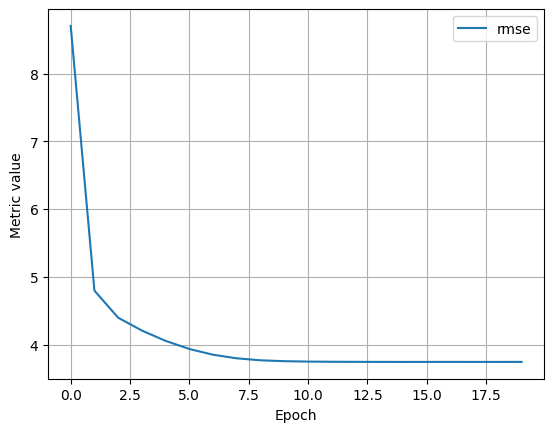

In [11]:
#@title Code - Experiment 1

# The following variables are the hyperparameters.
settings_1 = ml_edu.experiment.ExperimentSettings(
    learning_rate = 0.001,
    number_epochs = 20,
    batch_size = 50,
    input_features = ['TRIP_MILES']
)

metrics = [keras.metrics.RootMeanSquaredError(name='rmse')]

model_1 = create_model(settings_1, metrics)

experiment_1 = train_model('one_feature', model_1, training_df, 'FARE', settings_1)

ml_edu.results.plot_experiment_metrics(experiment_1, ['rmse'])
ml_edu.results.plot_model_predictions(experiment_1, training_df, 'FARE')

Epoch 1/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 1s 741us/step - loss: 1309.5222 - rmse: 36.1707
Epoch 2/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 0s 756us/step - loss: 835.5201 - rmse: 28.8888
Epoch 3/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 0s 708us/step - loss: 467.4473 - rmse: 21.6029
Epoch 4/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 1s 765us/step - loss: 215.8998 - rmse: 14.6620
Epoch 5/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 0s 740us/step - loss: 63.3486 - rmse: 7.9142
Epoch 6/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 0s 740us/step - loss: 16.3375 - rmse: 4.0396
Epoch 7/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 0s 732us/step - loss: 14.4047 - rmse: 3.7893
Epoch 8/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 0s 744us/step - loss: 14.2099 - rmse: 3.7628
Epoch 9/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 0s 733us/step - loss: 14.9632 - rmse: 3.8635
Epoch 10/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 0s 727us/step - loss: 14.1918 - rmse: 3.7600
Epoch 11/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 0s 725us/step - loss: 15.8767 - rmse: 3.9709
Epoch 12/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 1s 765us/step

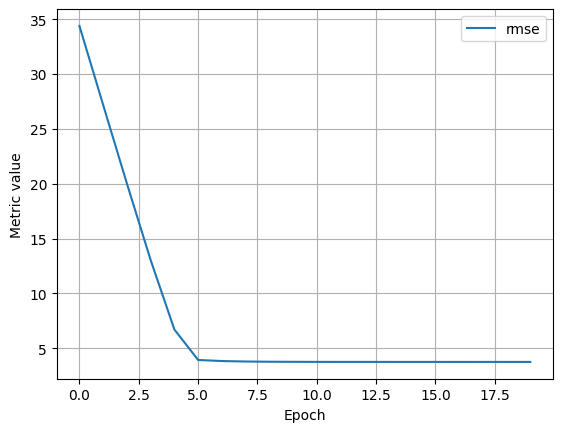

In [12]:
#@title Code - Experiment 2

# The following variables are the hyperparameters.
# TODO - Adjust these hyperparameters to see how they impact a training run.
settings_2 = ml_edu.experiment.ExperimentSettings(
    learning_rate = 0.001,
    number_epochs = 20,
    batch_size = 50,
    input_features = ['TRIP_MILES']
)

metrics = [keras.metrics.RootMeanSquaredError(name='rmse')]

model_2 = create_model(settings_2, metrics)

experiment_2 = train_model('one_feature_hyper', model_2, training_df, 'FARE', settings_2)

ml_edu.results.plot_experiment_metrics(experiment_2, ['rmse'])
ml_edu.results.plot_model_predictions(experiment_2, training_df, 'FARE')

Epoch 1/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 1s 805us/step - loss: 2267.7219 - rmse: 47.5084
Epoch 2/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 1s 785us/step - loss: 610.7433 - rmse: 24.5272
Epoch 3/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 0s 748us/step - loss: 29.2765 - rmse: 5.3491
Epoch 4/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 0s 744us/step - loss: 13.0406 - rmse: 3.5988
Epoch 5/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 0s 762us/step - loss: 13.6506 - rmse: 3.6869
Epoch 6/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 0s 762us/step - loss: 11.6608 - rmse: 3.4111
Epoch 7/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 0s 750us/step - loss: 12.8258 - rmse: 3.5770
Epoch 8/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 1s 770us/step - loss: 11.2201 - rmse: 3.3402
Epoch 9/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 0s 746us/step - loss: 12.5319 - rmse: 3.5250
Epoch 10/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 0s 750us/step - loss: 11.7367 - rmse: 3.4224
Epoch 11/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 0s 752us/step - loss: 12.6401 - rmse: 3.5517
Epoch 12/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 0s 726us/step - l

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


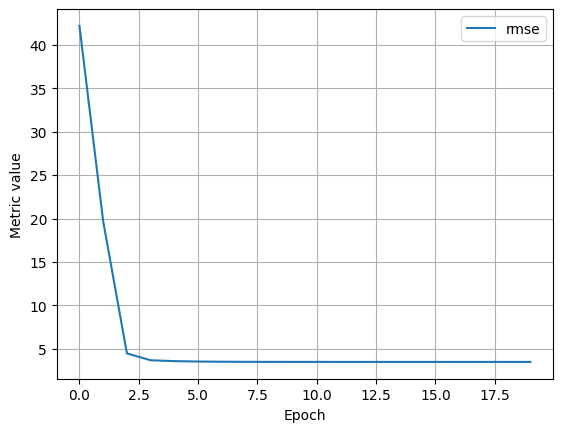

In [13]:
#@title Code - Experiment 3

# The following variables are the hyperparameters.
settings_3 = ml_edu.experiment.ExperimentSettings(
    learning_rate = 0.001,
    number_epochs = 20,
    batch_size = 50,
    input_features = ['TRIP_MILES', 'TRIP_MINUTES']
)

training_df['TRIP_MINUTES'] = training_df['TRIP_SECONDS']/60

metrics = [keras.metrics.RootMeanSquaredError(name='rmse')]

model_3 = create_model(settings_3, metrics)

experiment_3 = train_model('two_features', model_3, training_df, 'FARE', settings_3)

ml_edu.results.plot_experiment_metrics(experiment_3, ['rmse'])
ml_edu.results.plot_model_predictions(experiment_3, training_df, 'FARE')

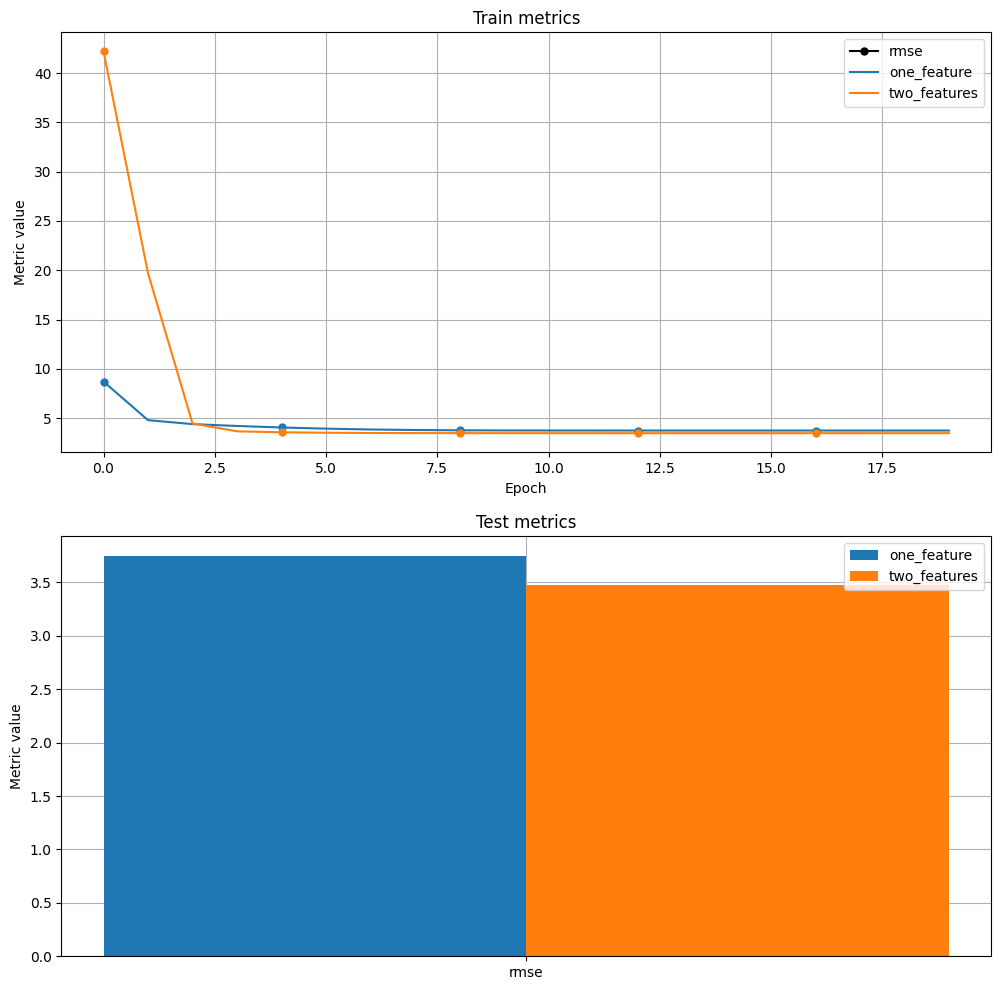

In [14]:
ml_edu.results.compare_experiment([experiment_1,experiment_3],['rmse'], training_df, training_df['FARE'].values)

In [15]:
#@title Code - Define functions to make predictions
def format_currency(x):
  return "${:.2f}".format(x)

def build_batch(df, batch_size):
  batch = df.sample(n=batch_size).copy()
  batch.set_index(np.arange(batch_size), inplace=True)
  return batch

def predict_fare(model, df, features, label, batch_size=50):
  batch = build_batch(df, batch_size)
  predicted_values = model.predict_on_batch(x={name: batch[name].values for name in features})

  data = {"PREDICTED_FARE": [], "OBSERVED_FARE": [], "L1_LOSS": [],
          features[0]: [], features[1]: []}
  for i in range(batch_size):
    predicted = predicted_values[i][0]
    observed = batch.at[i, label]
    data["PREDICTED_FARE"].append(format_currency(predicted))
    data["OBSERVED_FARE"].append(format_currency(observed))
    data["L1_LOSS"].append(format_currency(abs(observed - predicted)))
    data[features[0]].append(batch.at[i, features[0]])
    data[features[1]].append("{:.2f}".format(batch.at[i, features[1]]))

  output_df = pd.DataFrame(data)
  return output_df

def show_predictions(output):
  header = "-" * 80
  banner = header + "\n" + "|" + "PREDICTIONS".center(78) + "|" + "\n" + header
  print(banner)
  print(output)
  return

In [16]:
output = predict_fare(experiment_3.model, training_df, experiment_3.settings.input_features, 'FARE')
show_predictions(output)

--------------------------------------------------------------------------------
|                                 PREDICTIONS                                  |
--------------------------------------------------------------------------------
   PREDICTED_FARE OBSERVED_FARE L1_LOSS  TRIP_MILES TRIP_MINUTES
0           $7.74         $7.25   $0.49        1.30         8.60
1           $9.76         $9.00   $0.76        1.88        14.28
2          $34.02        $34.25   $0.23       11.83        42.00
3          $43.22        $41.00   $2.22       16.60        39.00
4          $31.19        $31.75   $0.56       12.20        18.00
5          $35.66        $35.25   $0.41       13.58        29.27
6           $6.89         $6.25   $0.64        1.06         6.18
7          $24.21        $24.00   $0.21        8.46        21.92
8           $7.80         $7.50   $0.30        1.30         9.00
9          $18.19        $17.25   $0.94        5.60        20.35
10         $47.65        $47.00   $0.65   